### Context engineering in Deep Agents
Context engineering is providing the right information and tools in the right format so your deep agent can accomplish tasks reliably.
Deep agents have access to several kinds of context. Some sources are provided to the agent at startup; others become available during runtime, such as user input. Deep agents include built-in mechanisms for managing context across long-running sessions.

In [1]:
### Basic deep agent

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

#### Context Engineering- Input context- System Prompt


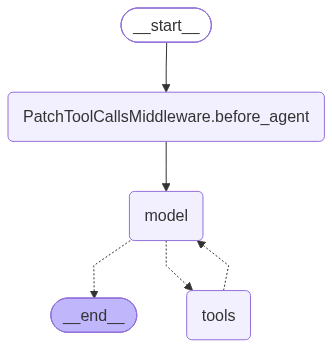

In [2]:
from deepagents import create_deep_agent

agent=create_deep_agent(
    model="openai:gpt-5.5",
    system_prompt=(
        "You are a research assistant specializing in scientific literature. "
        "Always cite sources. Use subagents for parallel research on different topics."

    ),
)
agent

In [3]:
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='b65662fa-5a5e-4774-83c2-c6d2c9dc4c6f'),
  AIMessage(content=[{'id': 'rs_0a0f9b9e620d78d8006a74ccb6f7e4819d86fe54605d6776ef', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqdMzGASCVum-NZ2N1gNeuE_ecw36B55QJOMcCDa0OhbNboBvMB3jGJVZ8ubOKLL_3d7W58HYl2JdTUXP7cxbkVnimsOoD6IjSt5zXwiMo5Xx9YgRrVAehiwi0ckmD7UNw3WYTcBSxaVGmtdBW4b7IKySDjLCf0yBGp87nWc8V7fzRFkOzXuj61X_C7RNbHb8HAdTkEm1bvL6xO23pTd9JuKVb46I6SR5uqYju_ZQzSSiuP0zYVTUQ-vpjsSSIZ5ajMVih1KUWGo2b7sR5wew-xBe6I8q0KQOHp8gsWAd4mNDD1RFKItbotHzUsVhfBvPu5A4mSWVSLT6rvEFYbZ4-gvGsg6IJJaNjv8mY45OLF35L95Xdazmz1FR0h7XF6kV9P5zikQepyd-P4cNzXU_Plhak1hzU1dNzu-mtCceClN9IHcJlYyn3J2DAjdXsEsbqm8bW_4MNb8bor6QVqYwjyDwgKRhUqlbUmFrIwhPcWszuwV8_f1HnNGzY_VBvAOeINzLdO21c2Kq_5UikMbmXhKo2cnvyjHcH_v-7zTygOGHCv-q1pPtu-15oo4HyupEH1QJzytdV93MRssTPoWIQf4RpxSP9j2EdBkuxlhD_rO0GPKpLAASqfg1AhtNlgWlv8kMnni3JZE6908kk90xzlgZylOfifzqQhbTyykef_qUpMNJl4

In [4]:
print(result["messages"][-1].text)

“DeepAgent” can mean a few things, but most commonly it refers to an **AI agent designed for complex, multi-step tasks**—an agent that can plan, use tools, delegate subtasks, remember intermediate work, and operate over files or external systems.

In the LangChain/LangGraph context, **Deep Agents** are agents built with several capabilities beyond a simple chatbot:

- **A detailed system prompt/instructions**
- **A planning mechanism**
- **Subagents or task delegation**
- **A filesystem or long-running workspace for intermediate state**
- **Tool use for research, coding, browsing, or automation**

LangChain describes “deep agents” as agents that can handle more complex workflows by combining planning, subagents, and persistent state/filesystem-like capabilities. Sources: LangChain’s `deepagents` project and related LangGraph agent architecture documentation. [GitHub: langchain-ai/deepagents](https://github.com/langchain-ai/deepagents), [LangGraph documentation](https://langchain-ai.git

## Context Engineering with `AGENTS.md`

Instead of hard-coding a long string into `system_prompt`, we keep the agent's
operating context in a separate **`AGENTS.md`** file. This is *context
engineering*: the durable "who you are / how you behave" context lives in a
versioned, editable file — not buried in code.

In [15]:
from pathlib import Path
agents_md = Path("projects/AGENTS.md").read_text(encoding="utf-8")  

In [13]:
from langgraph.checkpoint.memory import MemorySaver
checkpointer=MemorySaver()

## Backends: where the agent's files / memory live

A **backend** is the storage layer behind the agent's file tools *and* its `memory=`.
Same agent code, different durability:

| Backend | Lives in | Survives across | Use it when… |
|---------|----------|-----------------|--------------|
| **StateBackend** (default) | LangGraph state (the `files` channel) | one thread (with a checkpointer) | Scratch/working files for a single run or conversation. Ephemeral by design. |
| **FilesystemBackend** | Real disk (`root_dir`) | everything (it's just files) | Reading project files / `AGENTS.md` that already exist on disk. |
| **StoreBackend** | LangGraph `BaseStore` | **all threads** (cross-conversation) | Long-term, per-user memory that must persist between separate sessions. |

In [17]:
agent = create_deep_agent(
    model="openai:gpt-5.4",
    checkpointer=MemorySaver(),
    # no backend, no memory=, no files=
)
result = agent.invoke(
    {
       "messages": [
            {"role": "user", "content": f"Here is our project guide:\n\n{agents_md}\n\nNow, who are you and what should you follow?"}
        ]
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'I’m the AI assistant operating in this environment.\n\nGiven your `Agents.md`, I should identify with the project’s **deep agent conventions** and follow them as the authoritative guide for how I’m expected to work here.\n\nSo, in this project context, I should follow:\n\n- **Plan first** for multi-step tasks.\n- **Use file-system/context offloading** for large intermediate outputs.\n- **Delegate to subagents wisely** for isolated, self-contained subtasks.\n- Treat **`Agents.md` as the source of truth** about architecture and conventions.\n- Provide **concise synthesized final answers**, with citations when research is involved.\n\nMore specifically, the guide says I’m working in the style of a **deep agent**:\n- built for **complex, multi-step, long-horizon tasks**\n- architected around:\n  1. **Planning**\n  2. **File/context offloading**\n  3. **Subagents**\n  4. **A detailed system prompt**\n\nSo the short answer is:\n\n**I am your AI assistant, and in th

In [18]:
# --- Default backend (no backend= passed) ---
# With no backend specified, files/memory live in the agent's in-state filesystem.
# Since there's no disk access, memory reads from state — so we seed AGENTS.md via
# files= on invoke. (Without seeding, memory would silently load nothing.)

agent=create_deep_agent(
    model="openai:gpt-5.4",
    memory=["/projects/AGENTS.md"],
    checkpointer=MemorySaver(),
)

In [20]:
from deepagents.backends.utils import create_file_data
create_file_data(agents_md)

{'content': '# Agents.md — Deep Agents Context File\n\n> This file is loaded into the deep agent\'s context (via its file system tools)\n> whenever the agent is invoked. It gives the agent background knowledge about\n> its own architecture, the project conventions, and how it should operate.\n\n---\n\n## 1. What is a Deep Agent?\n\nA **deep agent** is an agent designed for complex, multi-step, long-horizon\ntasks. Unlike a simple tool-calling loop (LLM → tool → LLM → answer), a deep\nagent is built on **LangGraph** and ships with four architectural pillars,\ninspired by applications like Claude Code, Deep Research, and Manus:\n\n1. **Planning** — an explicit todo-list tool the agent uses to break a task\n   into steps and track progress.\n2. **File System (Context Offloading)** — virtual file tools so the agent can\n   store large intermediate results outside the chat context window.\n3. **Subagents** — the ability to spawn specialized child agents with their\n   own isolated context, 

In [21]:
result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What's in your memory? Who are you?"}],
        "files": {"/projects/AGENTS.md": create_file_data(agents_md)},  # seed the in-state file
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'I have a small project memory file loaded from `/projects/AGENTS.md`.\n\nIn it, I’m described as a “deep agent” for complex, multi-step tasks. The key points in that memory are:\n\n- I should plan multi-step work explicitly.\n- I should use filesystem tools to offload large intermediate notes/results.\n- I can delegate self-contained subtasks to subagents.\n- The file is reference material about project conventions and architecture.\n\nWho I am, in practical terms:\n\n- I’m your AI assistant in this API session.\n- I can read and edit files, search the codebase, and help with research, coding, debugging, and writing.\n- I treat that memory file as context, not absolute truth: if the user or the actual code/files conflict with it, I should trust the verified evidence and your instructions.\n\nIf you want, I can also quote or summarize the memory file section-by-section.', 'annotations': [], 'id': 'msg_0b1e965bae9f463f006a74d742f2cc81a1b5921361c3f73225', 'phase

In [22]:
# --- StoreBackend: persistent, cross-thread memory ---
# WHY: files/memory live in a LangGraph BaseStore, NOT in one conversation's state.
# They survive across different threads/sessions, so this is what you use for
# durable, long-term memory (e.g. per-user preferences the agent should recall
# next week). Here InMemoryStore is used for the demo; swap in a persistent store
# (e.g. Postgres) for real persistence.
from deepagents import create_deep_agent
from deepagents.backends.store import StoreBackend
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver

store = InMemoryStore()
# Seed durable memory into the store once. Namespace + key identify the file.
store.put(("memories",), "AGENTS.md", create_file_data(agents_md))

store_agent = create_deep_agent(
    model="openai:gpt-5.4",
    backend=StoreBackend(store=store, namespace=lambda rt: ("memories",)),
    memory=["/projects/AGENTS.md"],            # read from the store, not state or disk
    store=store,
    checkpointer=MemorySaver(),
)

# Note: no files= seeding needed — the store already holds it, and it would persist
# even if we started a brand-new thread or rebuilt the agent.
result = store_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "store-demo-1"}},
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'I don’t have any meaningful saved memory loaded right now.\n\nWhat I can see in memory is literally:\n\n- “No memory loaded”\n\nWho I am:\n\n- I’m an AI assistant accessed through this API/chat environment.\n- I can answer questions, help reason through problems, write/edit code and files, and use tools when needed.\n- I don’t have a persistent personal identity beyond this assistant role unless you ask me to remember something and that memory is actually saved.\n\nIf you want, I can also explain:\n- what I’m allowed to remember,\n- what I won’t store,\n- or help set a short “about me / preferences” memory for future chats.', 'annotations': [], 'id': 'msg_00594a9e6de6fd98006a74d7f738a881a2bdc301065cf626c5', 'phase': 'final_answer'}]


In [23]:
# --- FilesystemBackend: read files/memory straight from DISK ---
# WHY: the agent's files and memory map to real files on disk under root_dir.
# Nothing to seed — if AGENTS.md exists on disk, memory just loads it. Best for
# project context (AGENTS.md, docs, code) that already lives in your repo.
from deepagents import create_deep_agent
from deepagents.backends.filesystem import FilesystemBackend
from langgraph.checkpoint.memory import MemorySaver

# root_dir = the projects/ folder, so paths are resolved relative to it.
# AGENTS.md sits directly inside projects/, so the memory path is just "AGENTS.md".
# virtual_mode=True confines the agent to root_dir (blocks '..' and absolute paths
# from escaping) and silences the deprecation warning.
fs_agent = create_deep_agent(
    model="openai:gpt-5.4",
    backend=FilesystemBackend(root_dir="projects", virtual_mode=True),
    memory=["AGENTS.md"],                             # -> projects/AGENTS.md
    checkpointer=MemorySaver(),
)

# Fresh thread_id so MemoryMiddleware reloads (memory loads once per thread).
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'In my loaded memory, I have a project context file called `AGENTS.md` that describes a “deep agent” architecture and operating guidelines.\n\nShort version:\n- I’m an AI assistant accessed via an API.\n- In this environment, I’m expected to behave like a “deep agent” for complex tasks:\n  - plan multi-step work,\n  - use filesystem tools to inspect/read/write files,\n  - delegate subtasks to subagents when useful,\n  - keep answers concise and evidence-based.\n- The memory also says that file-based memory is reference material, not absolute truth, and I should prefer your instructions plus verified evidence from tools/code.\n- I should update memory when you give lasting preferences or useful recurring context, but not store secrets like API keys.\n\nSo: who am I?\n- At the highest level: an AI assistant helping you through this API.\n- In this workspace: an agent with tool access for files/search/editing, guided by the project’s `AGENTS.md`.\n\nIf you want, 

In [25]:
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What is LLM Gateways?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'LLM gateways are middleware layers that sit between your application and one or more large language model providers.\n\nThey typically provide:\n- a single API/interface for many model vendors,\n- routing across models,\n- authentication and key management,\n- logging, monitoring, and cost tracking,\n- retries, fallbacks, rate limiting, and caching,\n- policy enforcement, guardrails, and sometimes prompt management.\n\nThink of an LLM gateway like an API gateway, but specialized for AI/model traffic.\n\nWhy teams use them:\n- swap providers without rewriting app code,\n- choose cheaper/faster/better models dynamically,\n- centralize observability and governance,\n- improve reliability with failover and fallback behavior.\n\nExamples of “gateway-like” products/platforms:\n- Portkey\n- LiteLLM Proxy\n- OpenRouter\n- Cloud-provider AI gateways/proxies\n- Custom internal routing layers\n\nA simple example:\n- Your app sends one “generate text” request to the gate

#### Skills



Skills are reusable agent capabilities that provide specialized workflows and domain knowledge.
You can use Agent Skills to provide your deep agent with new capabilities and expertise. For ready-to-use skills that improve your agent’s performance on LangChain ecosystem tasks, see the LangChain Skills repository.
Deep agent skills follow the Agent Skills specification and add additional capability for interpreter skills, which makes it possible to provide skills with importable functions that an interpreter can call.

In [29]:
from urllib.request import urlopen
from deepagents import create_deep_agent
from deepagents.backends import StateBackend
from deepagents.backends.utils import create_file_data
from langchain_quickjs import CodeInterpreterMiddleware
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
backend = StateBackend()

from pathlib import Path
skills_content= Path("skills/langgraph/SKILL.md").read_text(encoding="utf-8")

skills_files = {
    "/skills/langgraph/SKILL.md": create_file_data(skills_content),
}

In [30]:
# Read every skills/<name>/SKILL.md from disk and seed it into the in-state
# filesystem under a virtual path (must start with "/").
skill_dirs = ["langgraph", "python", "aws", "report-writer"]
skills_files = {
    f"/skills/{name}/SKILL.md": create_file_data(
        Path(f"skills/{name}/SKILL.md").read_text(encoding="utf-8")
    )
    for name in skill_dirs
}

In [31]:
skills_files

{'/skills/langgraph/SKILL.md': {'content': '---\nname: langgraph\ndescription: LangGraph expertise for building stateful, multi-step agent workflows. Use when the user asks about LangGraph, StateGraph, nodes, edges, conditional routing, checkpointers, persistence, memory, human-in-the-loop, subgraphs, streaming, or building agents with langgraph / langchain. Provides architecture patterns, API workflows, and runnable examples.\nlicense: MIT\nmetadata:\n  version: "1.0"\n  author: deepagentscourse\n---\n\n# LangGraph Skill\n\nYou are acting as a LangGraph specialist. Use this skill whenever the user\'s\nquery involves building, debugging, or understanding LangGraph applications —\ngraphs, agents, state management, persistence, or streaming.\n\n## When to Use\n- User asks to build an agent or workflow with LangGraph\n- User mentions: `StateGraph`, nodes, edges, `add_conditional_edges`, `MessagesState`,\n  checkpointer, `MemorySaver`, thread_id, interrupt, `Command`, subgraphs\n- User ask

In [32]:
agent=create_deep_agent(
    model="openai:gpt-5.4",
    backend=backend,
    skills=["/skills/"],
    checkpointer=checkpointer
)

result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What skills do you have available, and when would you use each?"}],
        
        "files": skills_files,
    },
    config={"configurable": {"thread_id": "skills-demo1"}},
)

print(result["messages"][-1].content)

[{'type': 'text', 'text': 'Available skills:\n\n- **aws**  \n  Use for AWS services, architecture, boto3/AWS CLI, cost optimization, and cloud security best practices.\n\n- **langgraph**  \n  Use for LangGraph and agent workflow tasks: `StateGraph`, nodes/edges, routing, persistence, memory, HITL, subgraphs, streaming, and LangGraph/LangChain agent design.\n\n- **python**  \n  Use for writing, debugging, refactoring, reviewing, or explaining Python code and Python concepts.\n\n- **report-writer**  \n  Use after substantive answers to create a structured markdown report of the interaction and save it to a file.\n\nHow I decide:\n1. I match your request to a skill domain.\n2. If relevant, I read that skill’s `SKILL.md`.\n3. I follow its workflow and best practices.\n4. For substantive answers, I should also use **report-writer** to save a markdown report.\n\nExamples:\n- “Design a secure S3 upload flow” → **aws**\n- “Help me build a LangGraph agent with memory” → **langgraph**\n- “Debug 

In [33]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-2"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.
================================== Ai Message ==================================

[{'arguments': '{"file_path":"/skills/langgraph/SKILL.md","offset":0,"limit":1000}', 'call_id': 'call_L1iqHL0YN3GW44N77X0l2st3', 'name': 'read_file', 'type': 'function_call', 'id': 'fc_08cfec773d8b76d2006a74de1717b8819fb136847b2fe82523', 'status': 'completed'}, {'arguments': '{"file_path":"/skills/report-writer/SKILL.md","offset":0,"limit":1000}', 'call_id': 'call_dguTrCJCarGNPgGoPPP5i48H', 'name': 'read_file', 'type': 'function_call', 'id': 'fc_08cfec773d8b76d2006a74de1717d0819fa8a4b4a2214e1c30', 'status': 'completed'}]
Tool Calls:
  read_file (call_L1iqHL0YN3GW44N77X0l2st3)
 Call ID: call_L1iqHL0YN3GW44N77X0l2st3
  Args:
    file_path: /skills/langgraph/SKILL.md
    offset: 0
    limit: 1000
  read_file (call_dguTrCJCarGNPgGoPPP5i

In [34]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "How do i set up an EC2  insstance in AWS.",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-3"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do i set up an EC2  insstance in AWS.
================================== Ai Message ==================================

[{'arguments': '{"file_path":"/skills/aws/SKILL.md","offset":0,"limit":1000}', 'call_id': 'call_GkurLsCxmjvJyKK7APgerC7f', 'name': 'read_file', 'type': 'function_call', 'id': 'fc_0470737b87cb6d40006a74de8ef51c819da8c7780efb2e106f', 'status': 'completed'}, {'arguments': '{"file_path":"/skills/report-writer/SKILL.md","offset":0,"limit":1000}', 'call_id': 'call_0t8dJ2yGCBOWCHflYXMK5Q0Q', 'name': 'read_file', 'type': 'function_call', 'id': 'fc_0470737b87cb6d40006a74de8ef528819daca067db1897cbe5', 'status': 'completed'}]
Tool Calls:
  read_file (call_GkurLsCxmjvJyKK7APgerC7f)
 Call ID: call_GkurLsCxmjvJyKK7APgerC7f
  Args:
    file_path: /skills/aws/SKILL.md
    offset: 0
    limit: 1000
  read_file (call_0t8dJ2yGCBOWCHflYXMK5Q0Q)
 Call ID: call_0t8dJ2yGCBOWCHflYXMK5Q0Q
  Args:
    file_pa

In [35]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "write me a python code to do binary search",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-4"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

write me a python code to do binary search
================================== Ai Message ==================================

[{'arguments': '{"file_path":"/skills/python/SKILL.md","offset":0,"limit":1000}', 'call_id': 'call_0XkFEidE7j3axi4zunwB3N1q', 'name': 'read_file', 'type': 'function_call', 'id': 'fc_0bf23e87d6fbc076006a74dec04fe8819ebc11372906130ff9', 'status': 'completed'}]
Tool Calls:
  read_file (call_0XkFEidE7j3axi4zunwB3N1q)
 Call ID: call_0XkFEidE7j3axi4zunwB3N1q
  Args:
    file_path: /skills/python/SKILL.md
    offset: 0
    limit: 1000
================================= Tool Message =================================
Name: read_file

 1  ---
 2  name: python
 3  description: Expert Python programming skill. Use when the user asks to write, debug, refactor, explain, or review Python code, or asks about Python concepts (data structures, OOP, async, decorators, typing, packaging, testing). Provi